# Task A

In [ ]:
# ! pip uninstall soundfile && pip install soundfile


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [2]:
base_path = '/kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/'

In [3]:
languages = ['Bengali', 'Gujarati', 'Hindi', 'Kannada', 'Malayalam', 
             'Marathi', 'Punjabi', 'Tamil', 'Telugu', 'Urdu']
selected_languages = ['Gujarati', 'Hindi', 'Marathi']

In [4]:
def extract_mfcc(file_path, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfccs
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def extract_mfccs_for_languages(languages, samples_per_language=5):
    mfccs_by_language = {}
    file_paths_by_language = {}
    
    for language in languages:
        language_path = os.path.join(base_path, language)
        all_files = os.listdir(language_path)
        selected_files = np.random.choice(all_files, min(samples_per_language, len(all_files)), replace=False)
        
        mfccs_list = []
        file_paths = []
        
        for file in selected_files:
            file_path = os.path.join(language_path, file)
            mfccs = extract_mfcc(file_path)
            
            if mfccs is not None:
                mfccs_list.append(mfccs)
                file_paths.append(file_path)
        
        mfccs_by_language[language] = mfccs_list
        file_paths_by_language[language] = file_paths
    
    return mfccs_by_language, file_paths_by_language

In [5]:
all_mfccs, all_file_paths = extract_mfccs_for_languages(languages, samples_per_language=10)
selected_mfccs, selected_file_paths = extract_mfccs_for_languages(selected_languages, samples_per_language=5)


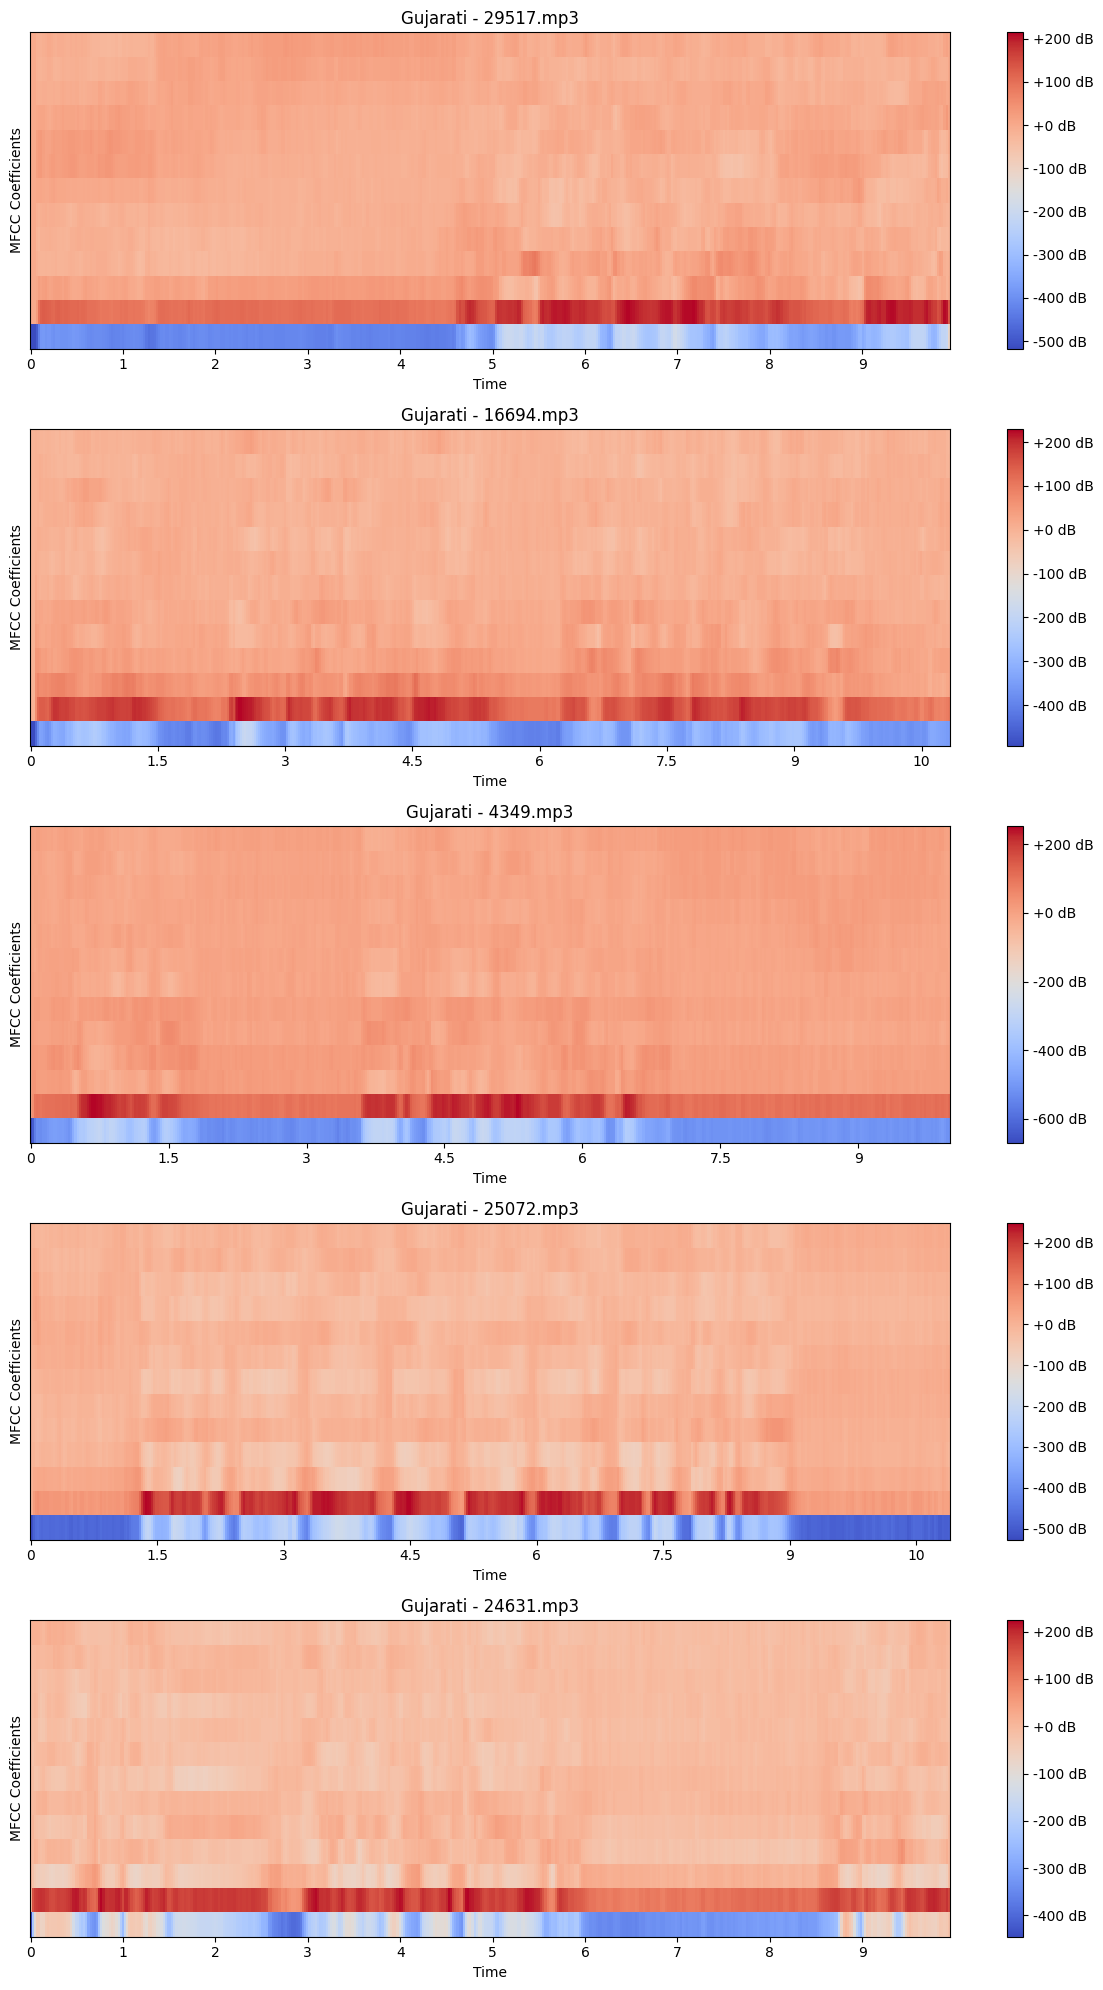

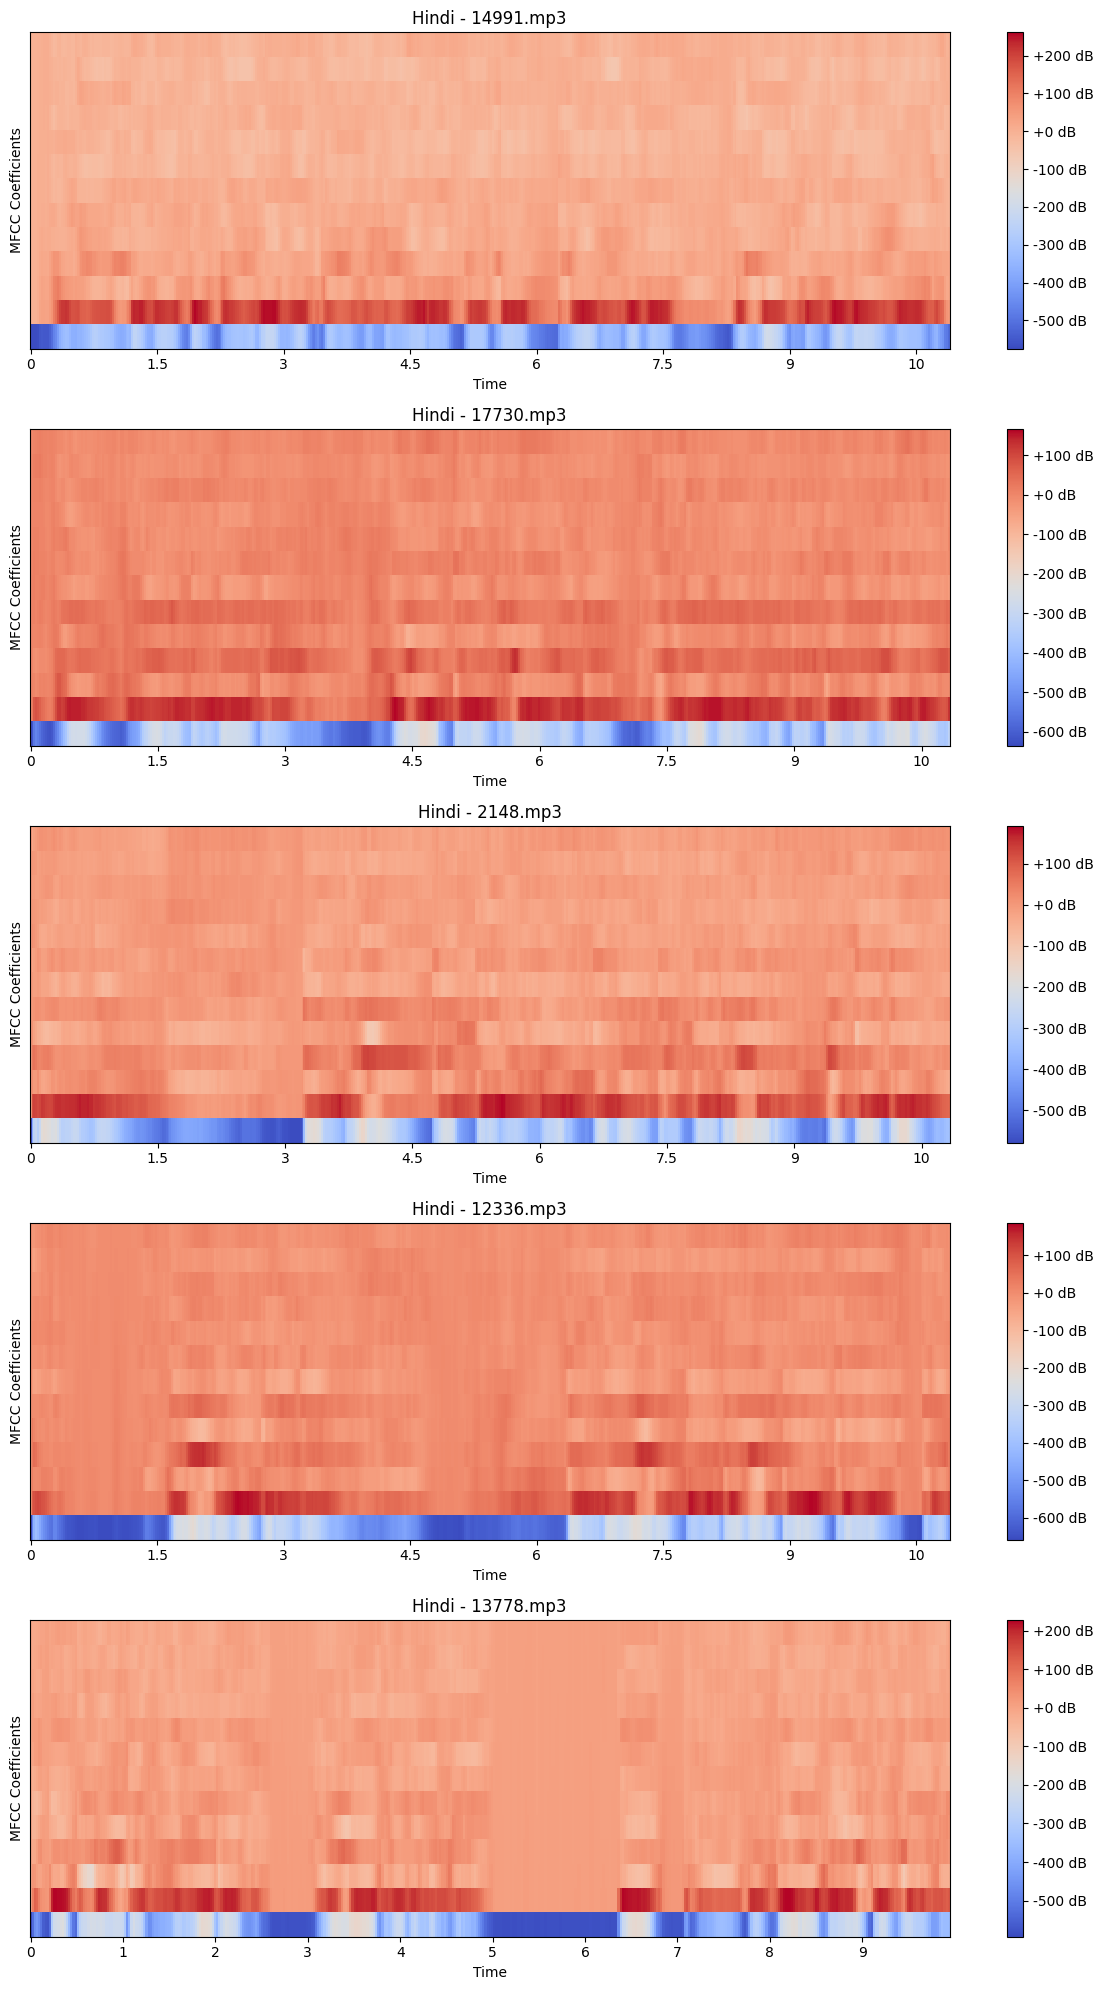

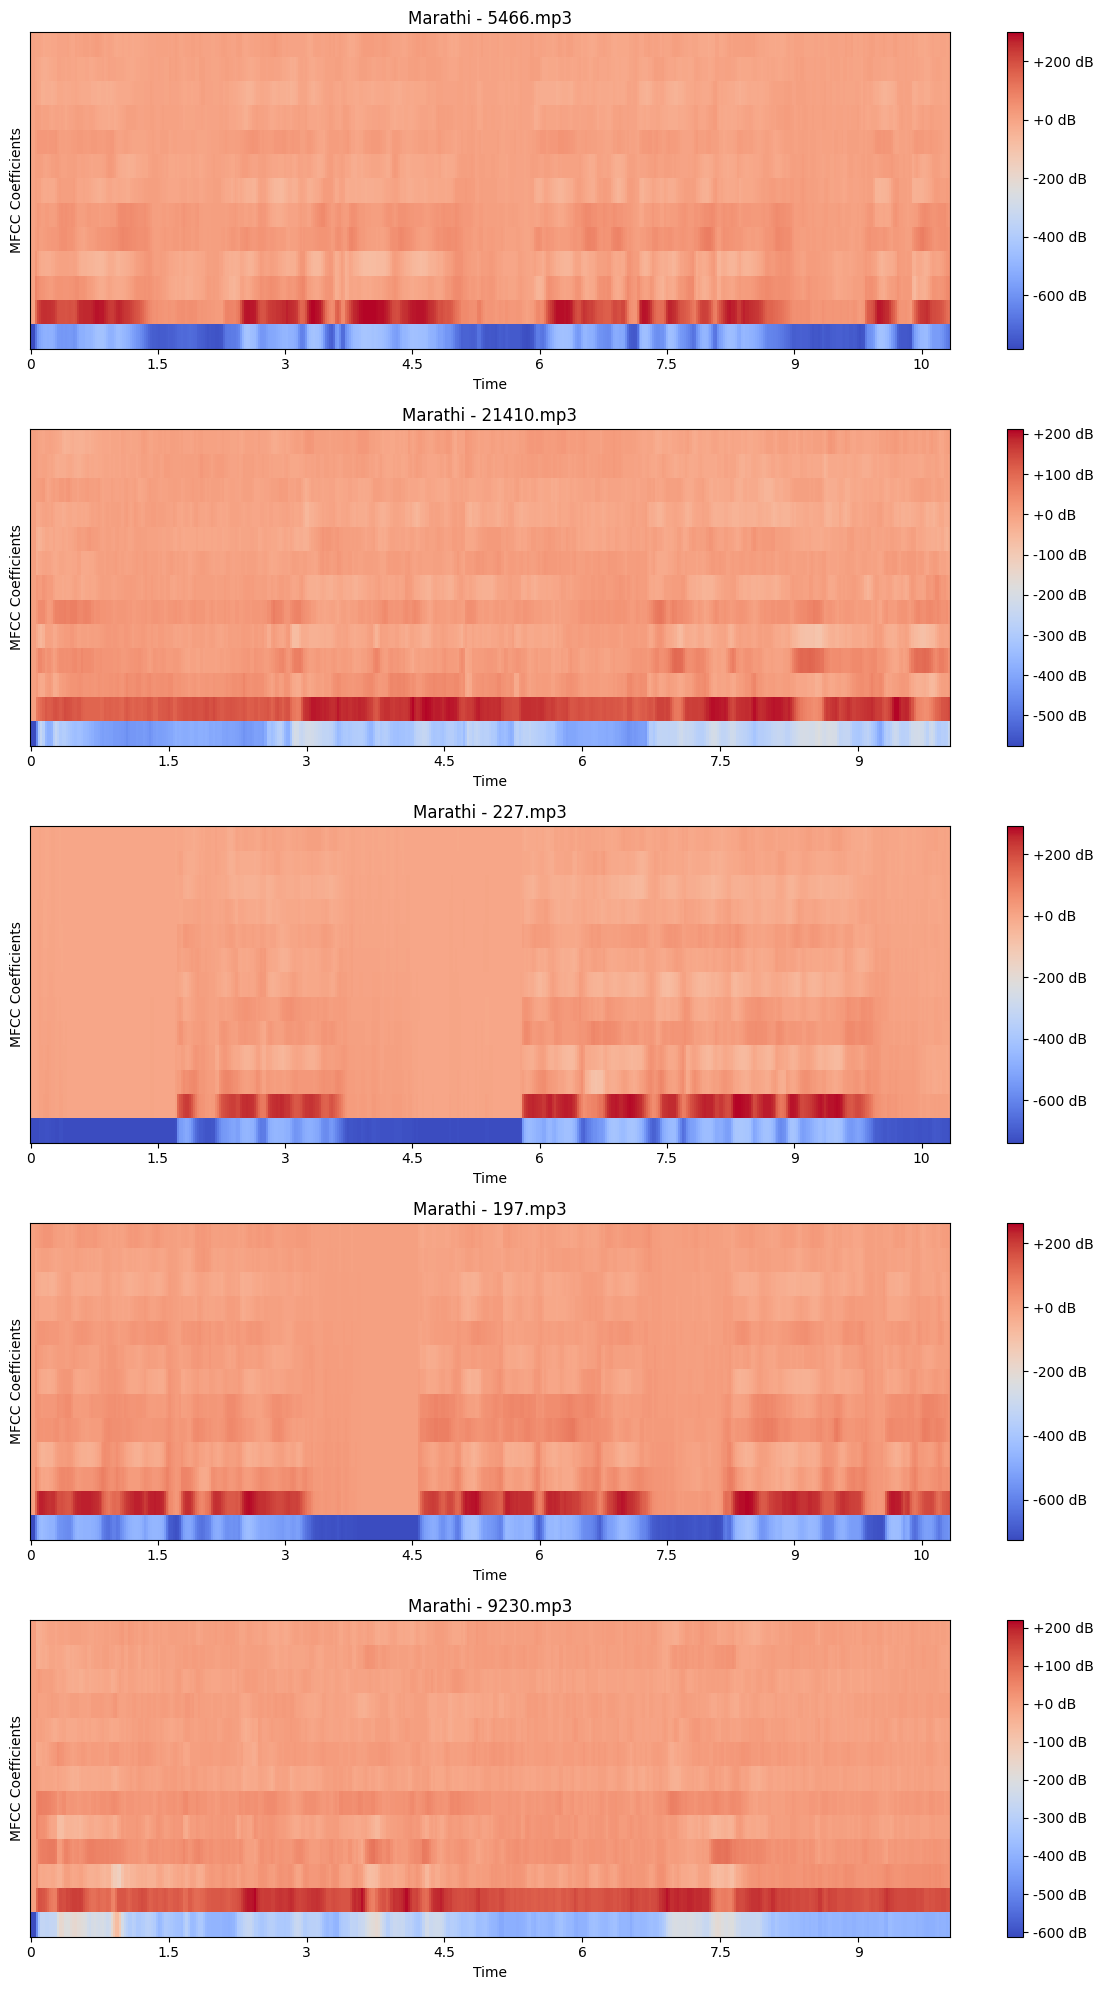

In [6]:
def visualize_mfccs(mfccs_by_language, file_paths_by_language, selected_languages):
    for language in selected_languages:
        mfccs_list = mfccs_by_language[language]
        file_paths = file_paths_by_language[language]
        
        fig, axes = plt.subplots(len(mfccs_list), 1, figsize=(12, 4 * len(mfccs_list)))
        
        if len(mfccs_list) == 1:
            axes = [axes]
        
        for i, (mfccs, file_path) in enumerate(zip(mfccs_list, file_paths)):
            filename = os.path.basename(file_path)
            librosa.display.specshow(mfccs, sr=22050, x_axis='time', ax=axes[i])
            axes[i].set_title(f'{language} - {filename}')
            axes[i].set_ylabel('MFCC Coefficients')
            fig.colorbar(axes[i].collections[0], ax=axes[i], format='%+2.0f dB')
        
        plt.tight_layout()
        plt.savefig(f'{language}_mfcc_spectrograms.png')
        plt.show()

visualize_mfccs(selected_mfccs, selected_file_paths, selected_languages)

In [7]:
def compute_mfcc_statistics(mfccs_by_language):

    statistics = []
    
    for language, mfccs_list in mfccs_by_language.items():
        if not mfccs_list:
            continue
            
        all_mfccs = np.concatenate(mfccs_list, axis=1)
        
        for i in range(all_mfccs.shape[0]):
            coef = all_mfccs[i, :]
            stats = {
                'Language': language,
                'MFCC_Coefficient': i,
                'Mean': np.mean(coef),
                'Std': np.std(coef),
                'Min': np.min(coef),
                'Max': np.max(coef),
                'Median': np.median(coef)
            }
            statistics.append(stats)
    
    return pd.DataFrame(statistics)

mfcc_statistics = compute_mfcc_statistics(all_mfccs)

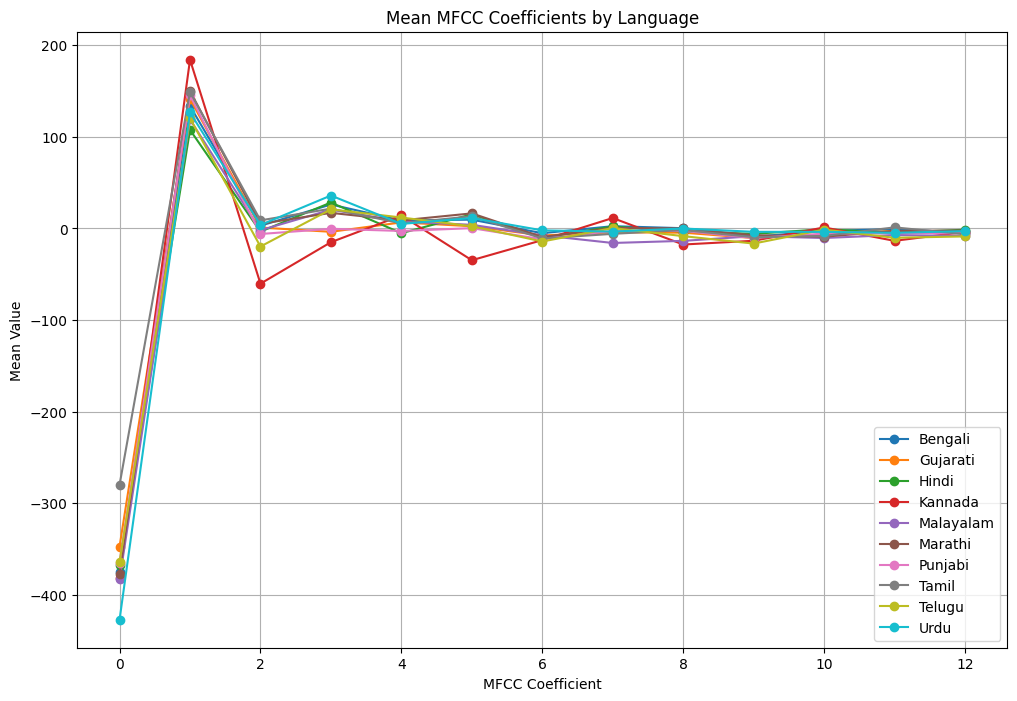

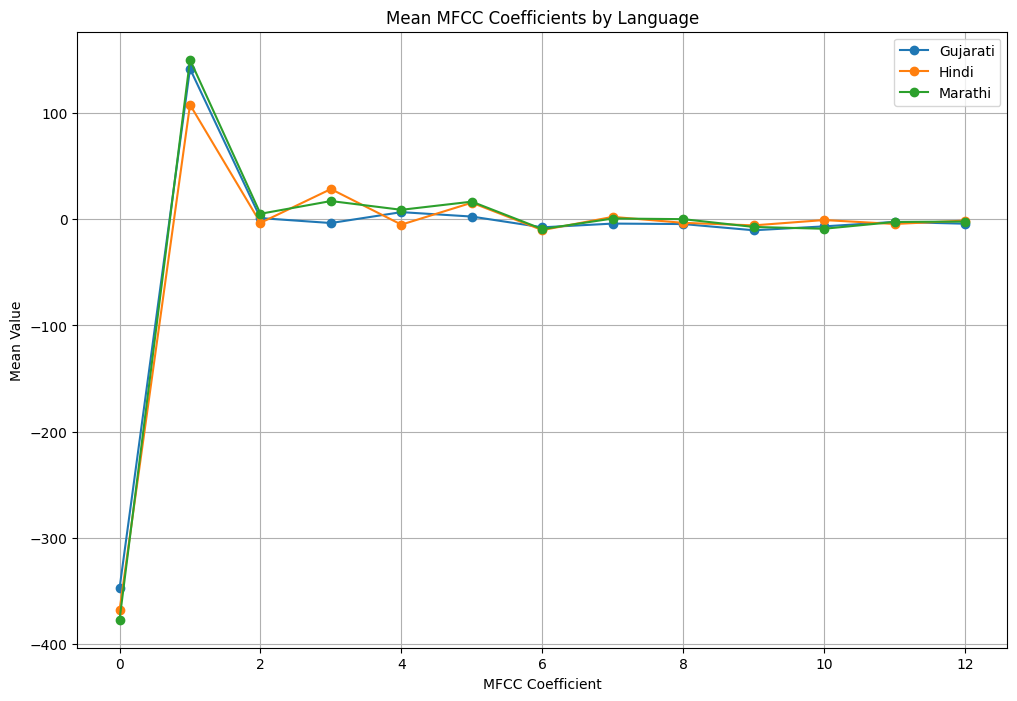

In [8]:
def plot_mean_mfccs(statistics_df, selected_languages=None):
    if selected_languages:
        df = statistics_df[statistics_df['Language'].isin(selected_languages)]
    else:
        df = statistics_df
    
    plt.figure(figsize=(12, 8))
    
    for language in df['Language'].unique():
        language_stats = df[df['Language'] == language]
        plt.plot(
            language_stats['MFCC_Coefficient'],
            language_stats['Mean'],
            marker='o',
            linestyle='-',
            label=language
        )
    
    plt.title('Mean MFCC Coefficients by Language')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Mean Value')
    plt.legend()
    plt.grid(True)
    plt.savefig('mean_mfcc_comparison.png')
    plt.show()

plot_mean_mfccs(mfcc_statistics)

plot_mean_mfccs(mfcc_statistics, selected_languages)

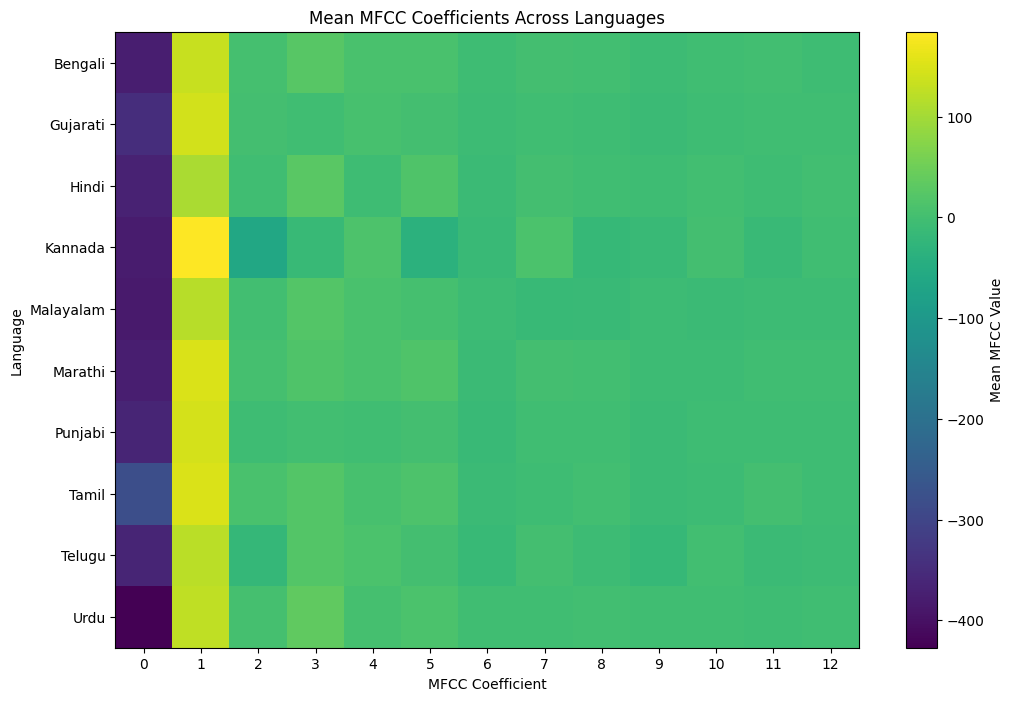

In [9]:
def create_mfcc_heatmap(statistics_df):
    pivot_df = statistics_df.pivot_table(
        index='Language',
        columns='MFCC_Coefficient',
        values='Mean'
    )
    
    plt.figure(figsize=(12, 8))
    plt.imshow(pivot_df, aspect='auto', cmap='viridis')
    plt.colorbar(label='Mean MFCC Value')
    plt.title('Mean MFCC Coefficients Across Languages')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Language')
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.savefig('mfcc_heatmap.png')
    plt.show()
    
    return pivot_df

mfcc_pivot = create_mfcc_heatmap(mfcc_statistics)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

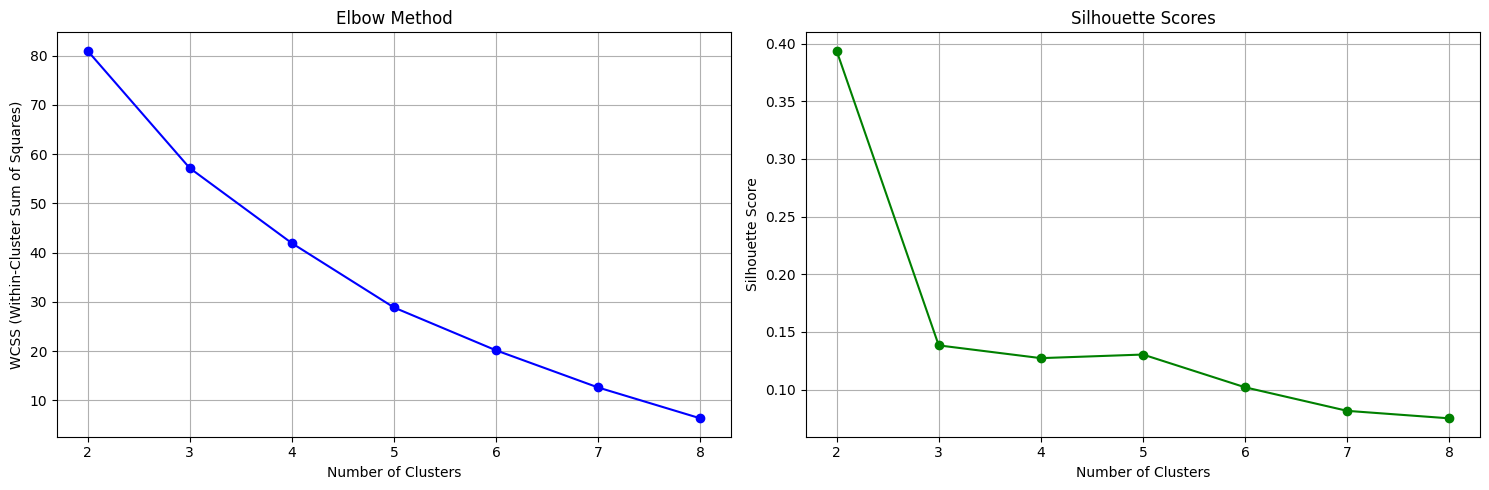

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


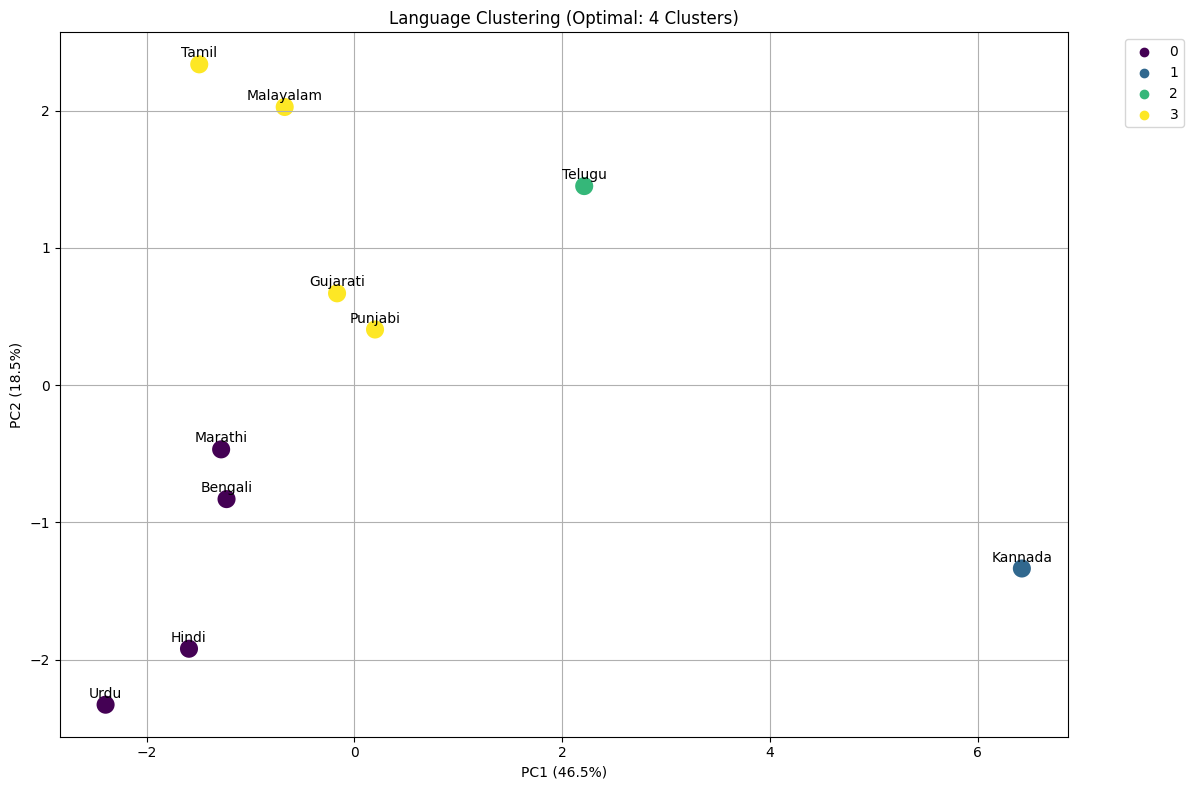

In [11]:
from sklearn.metrics import silhouette_score

def plot_elbow_and_silhouette(data, max_clusters=8):
    wcss = []
    silhouette_scores = []
    cluster_range = range(2, max_clusters+1)

    for n in cluster_range:
        kmeans = KMeans(n_clusters=n, random_state=42)
        labels = kmeans.fit_predict(data)
        
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(data, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(cluster_range, wcss, 'bo-')
    ax1.set_title('Elbow Method')
    ax1.set_xlabel('Number of Clusters')
    ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
    ax1.grid(True)
    
    ax2.plot(cluster_range, silhouette_scores, 'go-')
    ax2.set_title('Silhouette Scores')
    ax2.set_xlabel('Number of Clusters')
    ax2.set_ylabel('Silhouette Score')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('cluster_evaluation.png')
    plt.show()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(mfcc_pivot)

plot_elbow_and_silhouette(scaled_data, max_clusters=8)

optimal_clusters = 4  

def cluster_languages_optimal(mfcc_pivot, n_clusters=optimal_clusters):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(mfcc_pivot)
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(scaled_data)  # Use scaled data, not PCA result
    
    pca_df = pd.DataFrame(pca_result, 
                         columns=['PC1', 'PC2'], 
                         index=mfcc_pivot.index)
    pca_df['Cluster'] = clusters
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', 
                    palette='viridis', s=200)
    
    for language in pca_df.index:
        plt.annotate(language, 
                    (pca_df.loc[language, 'PC1'], pca_df.loc[language, 'PC2']),
                    textcoords="offset points",
                    xytext=(0,5),
                    ha='center')
    
    plt.title(f'Language Clustering (Optimal: {n_clusters} Clusters)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('optimal_clusters.png')
    plt.show()
    
    return pca_df

language_clusters = cluster_languages_optimal(mfcc_pivot)

# Task 2


In [12]:
def prepare_data_for_classification(mfccs_by_language):
    
    X = []
    y = []
    language_mapping = {}
    
    for i, (language, mfccs_list) in enumerate(mfccs_by_language.items()):
        language_mapping[i] = language
        
        for mfccs in mfccs_list:
            mfcc_mean = np.mean(mfccs, axis=1)
            mfcc_std = np.std(mfccs, axis=1)
            
            features = np.concatenate([mfcc_mean, mfcc_std])
            
            X.append(features)
            y.append(i)
    
    return np.array(X), np.array(y), language_mapping

In [13]:
def build_random_forest_classifier(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = RandomForestClassifier(n_estimators=100, random_state=random_state)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    return model, scaler, accuracy, report, conf_matrix, (X_train, X_test, y_train, y_test)


In [14]:
def plot_confusion_matrix(conf_matrix, language_mapping):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=[language_mapping[i] for i in range(len(language_mapping))],
        yticklabels=[language_mapping[i] for i in range(len(language_mapping))]
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()

In [15]:
def analyze_feature_importance(model):

    n_features = len(model.feature_importances_) // 2
    
    mean_importances = model.feature_importances_[:n_features]
    std_importances = model.feature_importances_[n_features:]
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(n_features), mean_importances)
    plt.title('Feature Importance: MFCC Means')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Importance')
    
    plt.subplot(1, 2, 2)
    plt.bar(range(n_features), std_importances)
    plt.title('Feature Importance: MFCC Standard Deviations')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()


In [16]:
def predict_language(model, scaler, file_path, language_mapping, n_mfcc=13):
    
    mfccs = extract_mfcc(file_path, n_mfcc)
    
    if mfccs is None:
        return "Error processing audio file"
    
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std = np.std(mfccs, axis=1)
    
    features = np.concatenate([mfcc_mean, mfcc_std]).reshape(1, -1)
    
    features_scaled = scaler.transform(features)
    
    prediction = model.predict(features_scaled)[0]
    
    return language_mapping[prediction]

Extracted MFCCs for 10 languages
Preparing data for classification...
Feature matrix shape: (10000, 26)
Number of classes: 10
Languages: ['Bengali', 'Gujarati', 'Hindi', 'Kannada', 'Malayalam', 'Marathi', 'Punjabi', 'Tamil', 'Telugu', 'Urdu']

Building and evaluating Random Forest classifier...
Random Forest Accuracy: 0.8470
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       200
           1       0.43      0.38      0.40       200
           2       0.94      0.99      0.96       200
           3       1.00      0.88      0.94       200
           4       0.95      0.96      0.96       200
           5       0.95      0.94      0.95       200
           6       0.44      0.49      0.46       200
           7       0.99      0.98      0.99       200
           8       0.97      0.94      0.96       200
           9       0.93      0.92      0.92       200

    accuracy                           0.85      2000


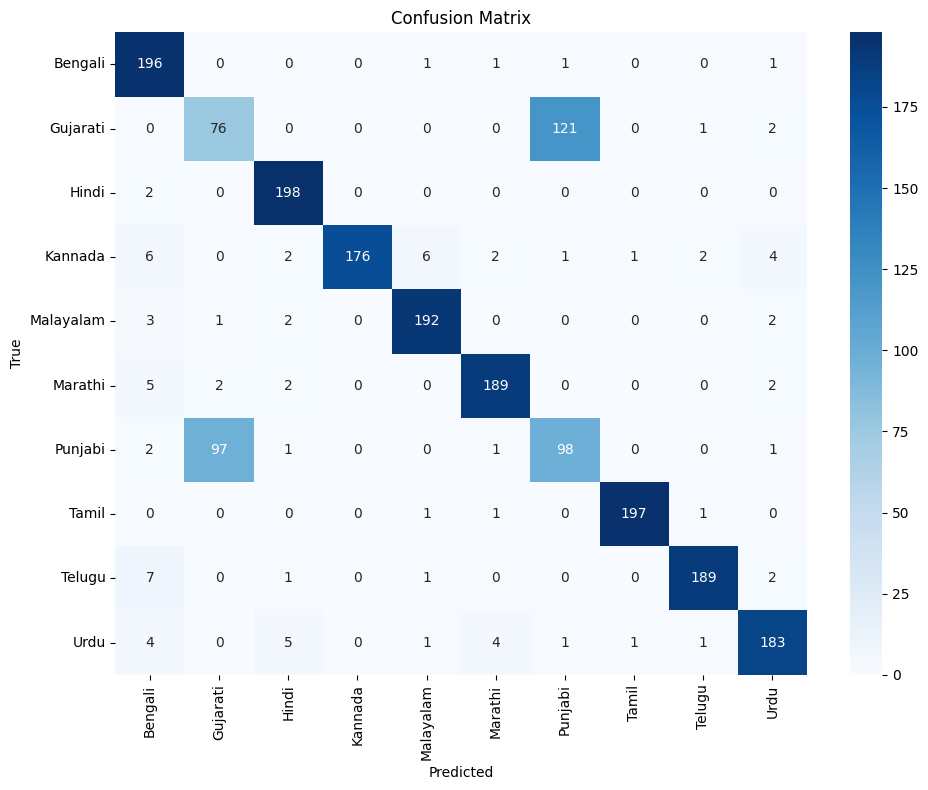


Analyzing feature importance...


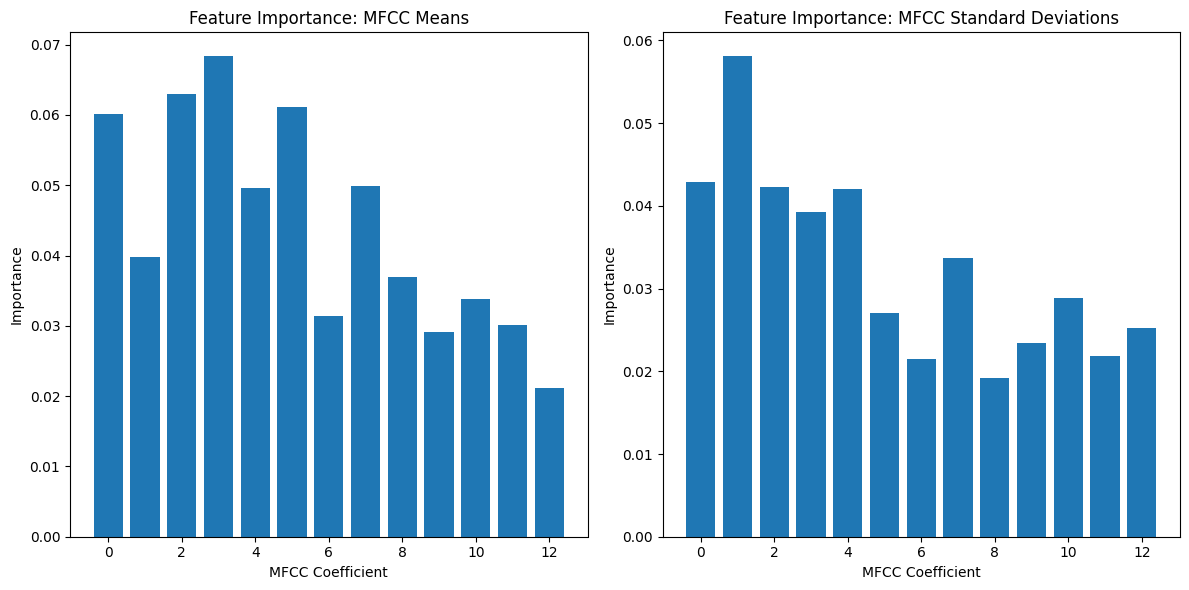

In [17]:
all_mfccs, all_file_paths = extract_mfccs_for_languages(languages, samples_per_language=1000)
print(f"Extracted MFCCs for {len(languages)} languages")

print("Preparing data for classification...")
X, y, language_mapping = prepare_data_for_classification(all_mfccs)
print(f"Feature matrix shape: {X.shape}")
print(f"Number of classes: {len(language_mapping)}")
print(f"Languages: {[language_mapping[i] for i in range(len(language_mapping))]}")

print("Building and evaluating Random Forest classifier...")
model, scaler, accuracy, report, confusion, (X_train, X_test, y_train, y_test) = build_random_forest_classifier(X, y)
print(f"Random Forest Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

print("Plotting confusion matrix...")
plot_confusion_matrix(confusion, language_mapping)

print("Analyzing feature importance...")
analyze_feature_importance(model)

In [18]:
print("\nTesting prediction with a sample audio file...")
sample_file_path = list(all_file_paths.values())[0][0]  
predicted_language = predict_language(model, scaler, sample_file_path, language_mapping)
print(f"Sample file: {sample_file_path}")
print(f"Predicted language: {predicted_language}")



Testing prediction with a sample audio file...
Sample file: /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Bengali/15056.mp3
Predicted language: Bengali
